# Benchmark Results: Improvement % Histograms
Plots the distribution of per-map improvement percentage (RepeatedTopK vs SP) across categories.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Load results
CSV_PATH = "benchmark_results.csv"  # adjust path as needed

results = []
with open(CSV_PATH, 'r') as f:
    for row in csv.DictReader(f):
        results.append(row)

# Parse improvements and categories
improvements = [float(r['improvement_pct']) for r in results]
categories = {}
for r in results:
    cat = r['label'].split('_')[0]
    categories.setdefault(cat, []).append(float(r['improvement_pct']))

print(f"Loaded {len(results)} maps across {len(categories)} categories")
for cat, vals in sorted(categories.items()):
    print(f"  {cat}: {len(vals)} maps, mean improvement: {np.mean(vals):.2f}%")

Loaded 150 maps across 4 categories
  dense: 45 maps, mean improvement: 1.34%
  lowblock: 45 maps, mean improvement: 1.17%
  six: 15 maps, mean improvement: -3.87%
  standard: 45 maps, mean improvement: 3.03%


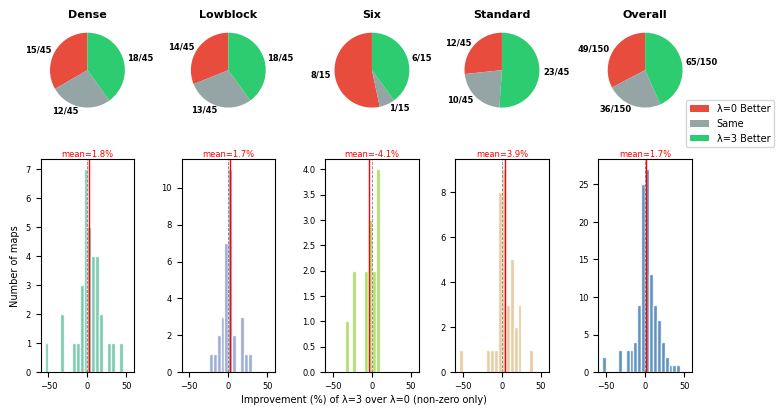

In [9]:
cat_names = sorted(categories.keys())
n_cols = len(cat_names) + 1

# IEEE full linewidth = 7.16 inches
fig_w = 7.16
fig_h = 4.0
fig, axes = plt.subplots(2, n_cols, figsize=(fig_w, fig_h),
                         constrained_layout=True,
                         gridspec_kw={'height_ratios': [1, 1.5]})

colors_cat = plt.cm.Set2(np.linspace(0, 1, n_cols))
pie_colors = ['#e74c3c', '#95a5a6', '#2ecc71']
pie_labels = ['λ=0 Better', 'Same', 'λ=3 Better']

# Shared x-axis: symmetric range, 5% bin width
all_vals = np.array(improvements)
nonzero_all = all_vals[all_vals != 0]
abs_max = max(abs(nonzero_all.min()), abs(nonzero_all.max()))
x_lim = int(np.ceil(abs_max / 5) * 5) + 5
bins = np.arange(-x_lim, x_lim + 5, 5)

def plot_column(ax_pie, ax_hist, vals, title, color):
    vals = np.array(vals)
    n = len(vals)
    n_neg = int(np.sum(vals < 0))
    n_zero = int(np.sum(vals == 0))
    n_pos = int(np.sum(vals > 0))
    counts = [n_neg, n_zero, n_pos]

    wedge_colors = [c for c, cnt in zip(pie_colors, counts) if cnt > 0]
    wedge_counts = [cnt for cnt in counts if cnt > 0]
    # Build labels as "count/total"
    wedge_labels = [f'{cnt}/{n}' for cnt in wedge_counts]

    wedges, texts = ax_pie.pie(
        wedge_counts, colors=wedge_colors, labels=wedge_labels,
        startangle=90, textprops={'fontsize': 6, 'fontweight': 'bold'})
    ax_pie.set_title(title, fontsize=8, fontweight='bold', pad=4)

    nonzero = vals[vals != 0]
    if len(nonzero) > 0:
        ax_hist.hist(nonzero, bins=bins, color=color, edgecolor='white', alpha=0.85)
        ax_hist.axvline(0, color='black', linestyle='--', linewidth=0.6, alpha=0.5)
        ax_hist.axvline(np.mean(nonzero), color='red', linestyle='-', linewidth=1)
        ax_hist.set_title(f'mean={np.mean(nonzero):.1f}%', fontsize=6,
                          color='red', pad=2)
    else:
        ax_hist.text(0.5, 0.5, 'All tied at 0%', transform=ax_hist.transAxes,
                     ha='center', va='center', fontsize=7)
    ax_hist.set_xlim(-x_lim, x_lim)
    # ax_hist.set_xlabel('Improvement (%) of λ=3 over λ=0\n(non-zero only)', fontsize=7)
    ax_hist.tick_params(labelsize=6)

for i, cat in enumerate(cat_names):
    plot_column(axes[0, i], axes[1, i], categories[cat],
                cat.replace('_', ' ').title(), colors_cat[i])

plot_column(axes[0, -1], axes[1, -1], improvements, 'Overall', 'steelblue')

fig.text(0.5, -0.02, 'Improvement (%) of λ=3 over λ=0 (non-zero only)', 
         ha='center', fontsize=7)

axes[1, 0].set_ylabel('Number of maps', fontsize=7)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=l) for c, l in zip(pie_colors, pie_labels)]
fig.legend(handles=legend_handles, loc='upper right', ncol=1,
           fontsize=7, frameon=True,
           bbox_to_anchor=(1.08, 0.75))

# fig.suptitle('Comparison of λ=0 vs λ=3 on Procedurally Generated Maps',
#              fontsize=9, fontweight='bold')

plt.savefig('improvement_histograms.png', dpi=300, bbox_inches='tight')
plt.savefig('improvement_histograms.pdf', bbox_inches='tight')
plt.show()

In [3]:
# Summary stats table
print(f"{'Category':<15} {'N':>4} {'Mean':>8} {'Median':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'% > 0':>7}")
print('-' * 70)
for cat in cat_names:
    v = np.array(categories[cat])
    pct_pos = 100 * np.sum(v > 0) / len(v)
    print(f"{cat:<15} {len(v):>4} {v.mean():>8.2f} {np.median(v):>8.2f} "
          f"{v.std():>8.2f} {v.min():>8.2f} {v.max():>8.2f} {pct_pos:>6.1f}%")
print('-' * 70)
v = np.array(all_vals)
pct_pos = 100 * np.sum(v > 0) / len(v)
print(f"{'Overall':<15} {len(v):>4} {v.mean():>8.2f} {np.median(v):>8.2f} "
      f"{v.std():>8.2f} {v.min():>8.2f} {v.max():>8.2f} {pct_pos:>6.1f}%")

Category           N     Mean   Median      Std      Min      Max   % > 0
----------------------------------------------------------------------
dense             45     1.34     0.00    15.41   -51.80    44.55   40.0%
lowblock          45     1.17     0.00     9.11   -22.24    25.16   40.0%
six               15    -3.87    -0.30    11.65   -30.64     9.67   40.0%
standard          45     3.03     0.39    12.71   -51.39    37.51   51.1%
----------------------------------------------------------------------
Overall          150     1.28     0.00    12.72   -51.80    44.55   43.3%
